# Wing scan keypoint-matching with SIFT

## Download data

Our data set is hosted at Hugging Face. You can use this code to directly download it. If you have already downloaded the data set, point the DATA_DIR constant to it.

In [1]:
from huggingface_hub import snapshot_download
import os

# point this constant to the folder you want to download the data into
DATA_DIR = r"D:\wingprint_paper\scanner_data"

#local_dir = snapshot_download(
#    repo_id="j-dey/bats-wing-print-scans",
#    repo_type="dataset",
#    local_dir=DATA_DIR
#)

## Preparations

In [ ]:
import csv
import cv2
from datetime import datetime
import glob
import matplotlib.pyplot as plt
import numpy as np
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler
import os
import pandas as pd
import pathlib
import pickle
import random
import seaborn as sns
import shutil
import sys
from tqdm.notebook import tqdm

sys.path.append("..")

import metrics
import utils

SOURCE_DIR = os.path.join(DATA_DIR, "scans")
GALLERY_DIR = os.path.join(DATA_DIR, "recaptures_gallery")
QUERY_DIR = os.path.join(DATA_DIR, "recaptures_query")
STATS_DIR = os.path.join("stats", "sift")
CHECKPOINTS_DIR = os.path.join("checkpoints", "sift")

os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

sns.set_theme()

class ScanImage:
    def __init__(self, folder, file, kps, descriptors):
        self.folder = folder
        self.animal_id = int(os.path.basename(pathlib.Path(folder).parent))
        self.species = os.path.basename(pathlib.Path(folder).parent.parent)
        self.season = int(os.path.basename(folder).split("_")[0][6:])
        self.scan_number = int(os.path.basename(folder).split("_")[1])
        if file is not None:
            self.file = file
        else:
            self.file = glob.glob(os.path.join(folder, '**', '*.png'), recursive=True)[0]
        self.kps = kps
        self.descriptors = descriptors
        self.identifier = (self.animal_id, self.season, self.scan_number)

class PairingInfo:
    def __init__(self, matching_kps, inliers, prediction, match):
        self.matching_kps = matching_kps
        self.inliers = inliers
        self.prediction = prediction
        self.match = match

def lowe_test(matches, lowesRatio):
    return [m for m, n in matches if m.distance < lowesRatio * n.distance]

def matches(matcher, des1, des2):
    matches12 = matcher.knnMatch(des1, des2, k=2)
    matches21 = matcher.knnMatch(des2, des1, k=2)

    return (matches12, matches21)

def mutual_matches(matches12, matches21, lowesRatio):
    good12 = lowe_test(matches12, lowesRatio)
    good21 = lowe_test(matches21, lowesRatio)

    reverse_pairs = {(m.trainIdx, m.queryIdx) for m in good21}
    mutual = [m for m in good12 if (m.queryIdx, m.trainIdx) in reverse_pairs]
            
    return mutual

def compute_rootsift(img, sift):
    kp, des = sift.detectAndCompute(img, None)

    if des is None:
        return kp, None
    
    # L1-normalize
    des /= (np.linalg.norm(des, ord=1, axis=1, keepdims=True) + 1e-8)
    # Take square root
    des = np.sqrt(des)
    
    return kp, des

utils.seed_everything()
cv2.setRNGSeed(utils.SEED)# to make FLANN matcher deterministic

sift = cv2.SIFT_create()

# FLANN parameters for SIFT
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)  # higher = more accurate but slower

matcher = cv2.FlannBasedMatcher(index_params, search_params)

## Split data into gallery and query scans

The very first scan of an animal is placed in the gallery, while all consecutive scans are used as queries.

In [3]:
shutil.rmtree(GALLERY_DIR, ignore_errors=True)
shutil.rmtree(QUERY_DIR, ignore_errors=True)
os.makedirs(GALLERY_DIR, exist_ok=True)
os.makedirs(QUERY_DIR, exist_ok=True)

recapture_individuals = []
other_individuals = []

for species in tqdm(glob.glob(os.path.join(SOURCE_DIR, '*'))):
    for individual in glob.glob(os.path.join(species, '*')):
        scans = glob.glob(os.path.join(individual, '*'))

        if len(scans) > 1:
            recapture_individuals.append(os.path.basename(individual))
        else:
            other_individuals.append(os.path.basename(individual))

print(f"found {len(recapture_individuals)} individuals with multiple scans and {len(other_individuals)} other")

for species in tqdm(glob.glob(os.path.join(SOURCE_DIR, '*'))):
    for individual in glob.glob(os.path.join(species, '*')):
        scans = glob.glob(os.path.join(individual, '*'))

        if os.path.basename(individual) in recapture_individuals:
            first_scan = scans[0]
            later_scans = scans[1:]

            target_path = pathlib.Path(GALLERY_DIR).joinpath(pathlib.Path(first_scan).relative_to(pathlib.Path(SOURCE_DIR)))

            shutil.copytree(first_scan, target_path)

            for scan in later_scans:
                target_path = pathlib.Path(QUERY_DIR).joinpath(pathlib.Path(scan).relative_to(pathlib.Path(SOURCE_DIR)))
                shutil.copytree(scan, target_path)
        else:
            target_path = pathlib.Path(GALLERY_DIR).joinpath(pathlib.Path(scans[0]).relative_to(pathlib.Path(SOURCE_DIR)))

            shutil.copytree(scans[0], target_path)

gallery_folders = glob.glob(os.path.join(GALLERY_DIR, '*', '*', '*'))
query_folders = glob.glob(os.path.join(QUERY_DIR, '*', '*', '*'))

num_classes = len(gallery_folders)

  0%|          | 0/38 [00:00<?, ?it/s]

found 90 individuals with multiple scans and 497 other


  0%|          | 0/38 [00:00<?, ?it/s]

## Calculate SIFT descriptors

In [ ]:
stable_gallery = {}
skipped_files = 0

species_folders = glob.glob(os.path.join(GALLERY_DIR, '*'))

for species_folder in tqdm(species_folders):
    for indi_folder in glob.glob(os.path.join(species_folder, '*')):
        scan_folders = glob.glob(os.path.join(indi_folder, '*'))

        for folder in scan_folders:
            kp_list, des_list = [], []     

            file = sorted(glob.glob(os.path.join(folder, '**', '*.png'), recursive=True))[0]

            img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

            kp, des = compute_rootsift(img, sift)
            
            if len(des) > 0:
                stable_gallery[folder] = (file, kp, des)
            else:
                skipped_files += 1

gallery_values = [len(vs[1]) for vs in stable_gallery.values()]
gallery = [ScanImage(f, *stable_gallery[f]) for f in gallery_folders]

print(f"generated gallery with {len(gallery)} entries, calculated {np.mean(gallery_values):.2f} stable keypoints on average (std {np.std(gallery_values):.2f}), skipped {skipped_files} files")

stable_gallery = {}
skipped_files = 0

species_folders = glob.glob(os.path.join(QUERY_DIR, '*'))

for species_folder in tqdm(species_folders):
    for indi_folder in glob.glob(os.path.join(species_folder, '*')):
        scan_folders = glob.glob(os.path.join(indi_folder, '*'))

        for folder in scan_folders:
            file = sorted(glob.glob(os.path.join(folder, '**', '*.png'), recursive=True))[0]

            img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

            kp, des = compute_rootsift(img, sift)
            
            if len(des) > 0:
                stable_gallery[folder] = (file, kp, des)
            else:
                skipped_files += 1

query_values = [len(vs[1]) for vs in stable_gallery.values()]

queries = [ScanImage(f, *stable_gallery[f]) for f in query_folders]

print(f"generated queries with {len(queries)} entries, calculated {np.mean(query_values):.2f} stable keypoints on average (std {np.std(query_values):.2f}), skipped {skipped_files} files")

  0%|          | 0/38 [00:00<?, ?it/s]

generated gallery with 587 entries, calculated 3112.83 stable keypoints on average (std 826.98), skipped 0 files


  0%|          | 0/8 [00:00<?, ?it/s]

generated queries with 140 entries, calculated 3030.51 stable keypoints on average (std 709.10), skipped 0 files


## Generate a cache of matching keypoints

We generate a cache so we don't need to match the same images in every run of the optimization.<br>
This speeds up the optimization a lot but uses a lot of RAM (> 20 GB). If you don't have enough RAM, this cache could be optimized by saving only necessary parts of the calculated matching keypoints.

In [5]:
matches_cache = {}

for query_scan in tqdm(queries):
    for gallery_scan in gallery:
        matching_kps = matches(matcher, query_scan.descriptors, gallery_scan.descriptors)

        matches_cache[(query_scan.identifier, gallery_scan.identifier)] = matching_kps

  0%|          | 0/140 [00:00<?, ?it/s]

## Optimize Lowe's ratio

We optimize for the maximum accuracy while making sure that no input combinations are skipped because they yield too few matching keypoints.

In [ ]:
lowes_ratios = []
sequence_pairings = []
skipped_files = []

def constraints(trial):
    # skipped files must be <= 0
    return [abs(trial.user_attrs["skipped_files"])]

def objective(trial):
    lowes_ratio = trial.suggest_float('lowesRatio', 0.75, 0.99)
    targets = []
    predictions = []
    run_sequence_pairings = {}
    run_skipped_files = 0

    for query_scan in tqdm(queries):
        best_combination = None

        for gallery_scan in gallery:
            # reuse previously calculated matches
            matching_kps = mutual_matches(*matches_cache[(query_scan.identifier, gallery_scan.identifier)], lowes_ratio)

            # at this point, we don't know the number of inliers yet and therefore set them to None
            run_sequence_pairings[(query_scan.folder, gallery_scan.folder)] = PairingInfo(len(matching_kps), None, False, query_scan.animal_id == gallery_scan.animal_id)

            if len(matching_kps) >= 4: # we need at least 4 keypoints for a homography
                src_pts = np.float32([query_scan.kps[m.queryIdx].pt for m in matching_kps]).reshape(-1, 1, 2)
                dst_pts = np.float32([gallery_scan.kps[m.trainIdx].pt for m in matching_kps]).reshape(-1, 1, 2)

                _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

                if mask is not None:
                    num_inliers = np.sum(mask)

                    # add the number of inliers to the existing pairing
                    run_sequence_pairings[(query_scan.folder, gallery_scan.folder)].inliers = num_inliers

                    if best_combination is None or num_inliers > best_combination[2]:
                        best_combination = (gallery_scan, len(matching_kps), num_inliers)
                else:
                    run_skipped_files += 1
            else:
                run_skipped_files += 1
        
        if best_combination is not None:
            # flag the best pairing as the prediction
            run_sequence_pairings[(query_scan.folder, best_combination[0].folder)].prediction = True

            predicted_scan = best_combination[0]

            targets.append(query_scan.animal_id)
            predictions.append(predicted_scan.animal_id)

    # calculate accuracy as metric for the optimization
    accuracy = metrics.compute_accuracy(num_classes, predictions, targets)

    lowes_ratios.append(lowes_ratio)
    sequence_pairings.append(run_sequence_pairings)
    skipped_files.append(run_skipped_files)

    trial.set_user_attr("skipped_files", run_skipped_files)

    return accuracy

study = optuna.create_study(study_name="BatStudy", direction='maximize', sampler=TPESampler(seed=utils.SEED, constraints_func=constraints))
study.optimize(objective, n_trials=20, show_progress_bar=True)

c:\Users\julis\Desktop\WingPrint\Repos\WingPrint-Supervised\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

...

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

## Save a checkpoint file

In [7]:
with open(os.path.join(CHECKPOINTS_DIR, 'optimization_runs.pkl'), 'wb') as file:
    pickle.dump((lowes_ratios, sequence_pairings, skipped_files), file)

with open(os.path.join(CHECKPOINTS_DIR, 'optimization_runs.pkl'), 'rb') as file:
    (lowes_ratios, sequence_pairings, skipped_files) = pickle.load(file)

## Evaluate optimization of Lowe's ratio

  0%|          | 0/20 [00:00<?, ?it/s]

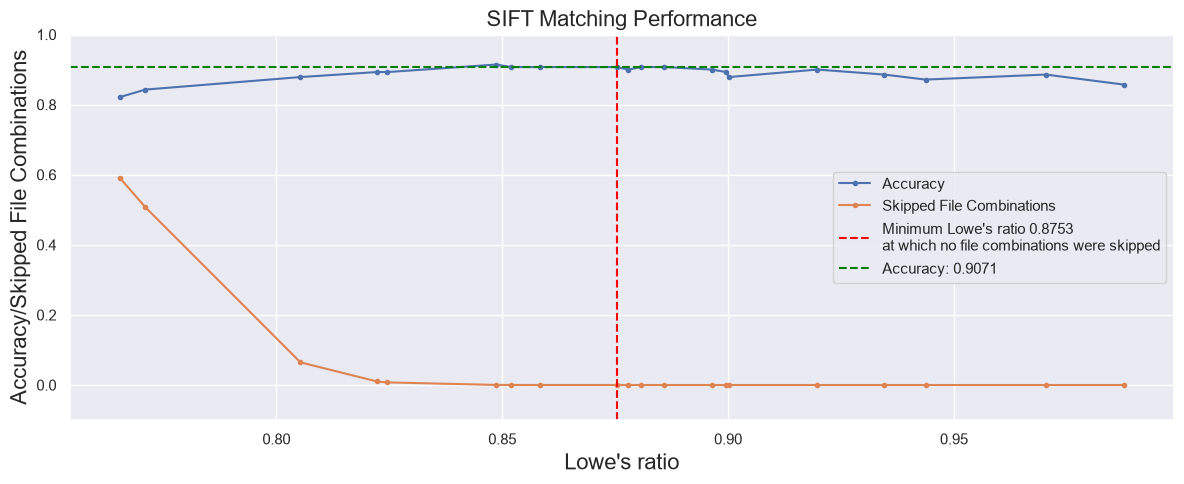

In [8]:
gathered_accuracies = []
gathered_skipped_files = []

for ratio, pairings, skipped in tqdm(zip(lowes_ratios, sequence_pairings, skipped_files), total=len(skipped_files)):
    targets = []
    predictions = []

    for (query_sequence, gallery_sequence), pairingInfo in pairings.items():
        query_scan = ScanImage(query_sequence, None, None, None)
        gallery_scan = ScanImage(gallery_sequence, None, None, None)

        if pairingInfo.prediction:
            predictions.append((query_sequence, gallery_scan.animal_id))

        if pairingInfo.match:
            targets.append((query_sequence, gallery_scan.animal_id))

    # ensure same length of of predictions and targets
    assert(len(predictions) == len(targets))

    # the lists can contain the queries in different order
    predictions.sort(key=lambda data: data[0])
    targets.sort(key=lambda data: data[0])

    # ensure that the lists contain the same queries
    assert all(p[0] == t[0] for p, t in zip(predictions, targets))

    # get rid of query info
    predictions = [p for (_, p) in predictions]
    targets = [t for (_, t) in targets]

    gathered_accuracies.append(metrics.compute_accuracy(num_classes, predictions, targets))
    gathered_skipped_files.append(skipped)

sorted_accuracies = [x for _, x in sorted(zip(lowes_ratios, gathered_accuracies))]
sorted_skipped_files = [x for _, x in sorted(zip(lowes_ratios, gathered_skipped_files))]
sorted_lowes_ratios = sorted(lowes_ratios)

# first occurrence of zero skipped files
minimum_combo = sorted_skipped_files.index(0)

minimal_lowes = sorted_lowes_ratios[minimum_combo]
optimized_accuracy = sorted_accuracies[minimum_combo]

plt.figure(figsize=(12, 5))

skipped_files_ratios = [x/(len(query_folders)*len(gallery_folders)) for x in sorted_skipped_files]

plt.plot(sorted_lowes_ratios, sorted_accuracies, marker='.', label=f"Accuracy")
plt.plot(sorted_lowes_ratios, skipped_files_ratios, marker='.', label="Skipped File Combinations")

plt.axvline(minimal_lowes, color="red", linestyle="--", label=f"Minimum Lowe's ratio {minimal_lowes:.4f}\nat which no file combinations were skipped")
plt.axhline(optimized_accuracy, color="green", linestyle="--", label=f"Accuracy: {optimized_accuracy:.4f}")

plt.xlabel("Lowe's ratio", fontdict = {'fontsize' : 16})
plt.ylabel("Accuracy/Skipped File Combinations", fontdict = {'fontsize' : 16})
plt.title("SIFT Matching Performance", fontdict = {'fontsize' : 16})
plt.legend()
plt.grid(True)
plt.ylim(bottom=-0.1, top=1)
plt.tight_layout()
plt.savefig(os.path.join(STATS_DIR, "Lowes_Ratio_Optimization.pdf"))

## Calculate and plot additional statistics

  0%|          | 0/82180 [00:00<?, ?it/s]

Skipped files: 0

Accuracy overall: 0.9071
F1 score overall: 0.9071
Accuracy within seasons: 0.9483
F1 score within seasons: 0.9483
Accuracy across seasons: 0.7083
F1 score across seasons: 0.7083

Mean matching keypoints between same individuals: 133.44 ± 70.99
Mean matching keypoints between different individuals: 49.05 ± 12.46
Mean inliers between same individuals: 74.77 ± 67.44
Mean inliers between different individuals: 5.83 ± 1.00


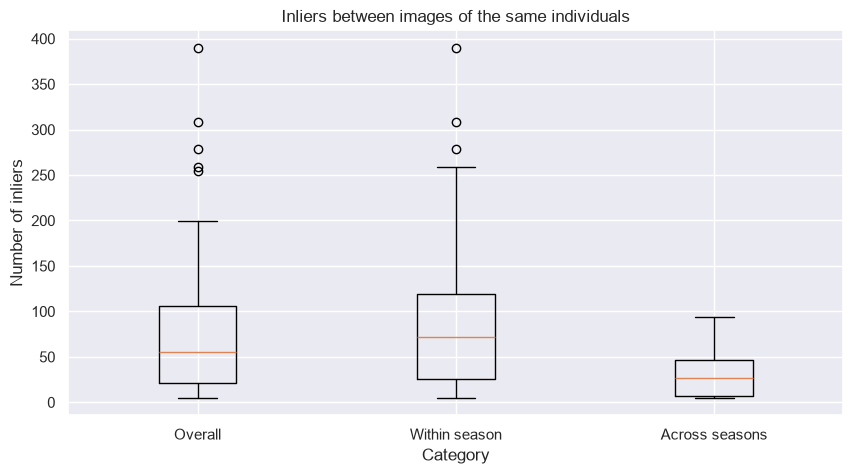

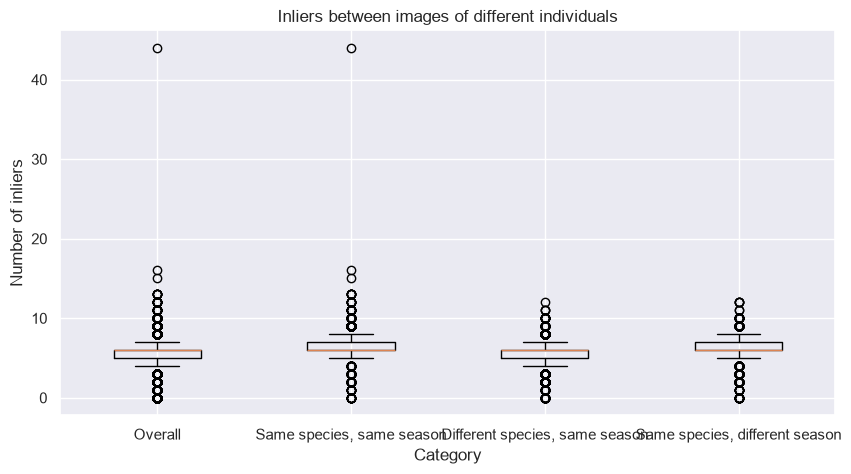

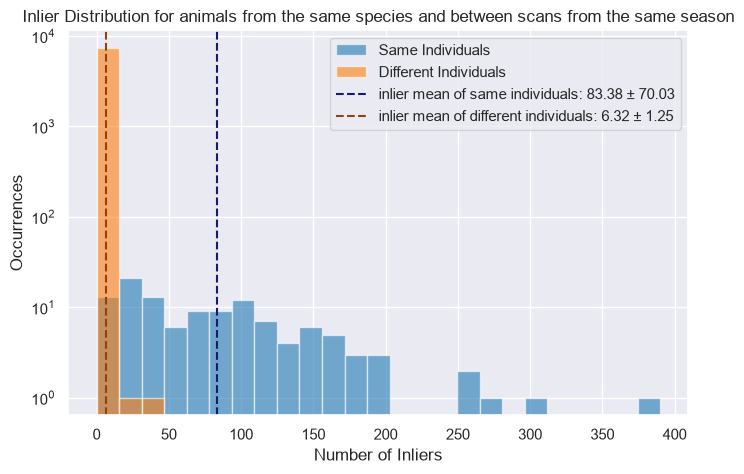

In [9]:
best_run = lowes_ratios.index(minimal_lowes)

# extract statistics of the best run
pairings = sequence_pairings[best_run]
skipped = skipped_files[best_run]

assert skipped == 0

matching_kps_matches = []
matching_kps_non_matches = []

inliers_matches = []
inliers_non_matches = []

inliers_matches_same_species_different_season = []
inliers_non_matches_same_species_different_season = []

inliers_non_matches_different_species_same_season = []

inliers_matches_same_species_same_season = []
inliers_non_matches_same_species_same_season = []

predictions_within_season = []
targets_within_season = []

predictions_across_seasons = []
targets_across_seasons = []

for (query_sequence, gallery_sequence), pairingInfo in tqdm(pairings.items()):
    query_scan = ScanImage(query_sequence, None, None, None)
    gallery_scan = ScanImage(gallery_sequence, None, None, None)

    if pairingInfo.match:
        matching_kps_matches.append(pairingInfo.matching_kps)
        inliers_matches.append(pairingInfo.inliers)

        if query_scan.season == gallery_scan.season:
            targets_within_season.append((query_sequence, gallery_scan.animal_id))

            if query_scan.species == gallery_scan.species:
                inliers_matches_same_species_same_season.append(pairingInfo.inliers)
        else:
            targets_across_seasons.append((query_sequence, gallery_scan.animal_id))

            if query_scan.species == gallery_scan.species:
                inliers_matches_same_species_different_season.append(pairingInfo.inliers)
    else:
        matching_kps_non_matches.append(pairingInfo.matching_kps)
        inliers_non_matches.append(pairingInfo.inliers)

        if query_scan.season == gallery_scan.season:
            if query_scan.species == gallery_scan.species:
                inliers_non_matches_same_species_same_season.append(pairingInfo.inliers)
            else:
                inliers_non_matches_different_species_same_season.append(pairingInfo.inliers)
        else:
            if query_scan.species == gallery_scan.species:
                inliers_non_matches_same_species_different_season.append(pairingInfo.inliers)

    if pairingInfo.prediction:
        # find ground truth for prediction to decide the season category (within season / across seasons)
        if pairingInfo.match:
            # this is the easiest case where the prediction actually is the ground truth
            # we test for this case first because it speeds up the whole process a lot
            if query_scan.season == gallery_scan.season:
                predictions_within_season.append((query_sequence, gallery_scan.animal_id))
            else:
                predictions_across_seasons.append((query_sequence, gallery_scan.animal_id))
        else:
            # in any other case we need to find the corresponding match
            for (q_seq_truth, g_seq_truth), pair in pairings.items():
                q_scan_truth = ScanImage(q_seq_truth, None, None, None)
                g_scan_truth = ScanImage(g_seq_truth, None, None, None)

                if pair.match and q_seq_truth == query_sequence:
                    if q_scan_truth.season == g_scan_truth.season:
                        predictions_within_season.append((query_sequence, gallery_scan.animal_id))
                    else:
                        predictions_across_seasons.append((query_sequence, gallery_scan.animal_id))
                
                    break

# ensure same length of of predictions and targets
assert(len(predictions_within_season) == len(targets_within_season))
assert(len(predictions_across_seasons) == len(targets_across_seasons))

# the lists can contain the queries in different order
predictions_within_season.sort(key=lambda data: data[0])
predictions_across_seasons.sort(key=lambda data: data[0])
targets_within_season.sort(key=lambda data: data[0])
targets_across_seasons.sort(key=lambda data: data[0])

# ensure that the lists contain the same queries
assert all(p[0] == t[0] for p, t in zip(predictions_within_season, targets_within_season))
assert all(p[0] == t[0] for p, t in zip(predictions_across_seasons, targets_across_seasons))

# get rid of query info
predictions_within_season = [p for (_, p) in predictions_within_season]
predictions_across_seasons = [p for (_, p) in predictions_across_seasons]
targets_within_season = [t for (_, t) in targets_within_season]
targets_across_seasons = [t for (_, t) in targets_across_seasons]

overall_accuracy = metrics.compute_accuracy(num_classes, predictions_within_season+predictions_across_seasons, targets_within_season+targets_across_seasons)
overall_f1_score = metrics.compute_f1_score(num_classes, predictions_within_season+predictions_across_seasons, targets_within_season+targets_across_seasons)

accuracy_within_seasons = metrics.compute_accuracy(num_classes, predictions_within_season, targets_within_season)
f1_score_within_seasons = metrics.compute_f1_score(num_classes, predictions_within_season, targets_within_season)

accuracy_across_seasons = metrics.compute_accuracy(num_classes, predictions_across_seasons, targets_across_seasons)
f1_score_across_seasons = metrics.compute_f1_score(num_classes, predictions_across_seasons, targets_across_seasons)

print(f"Skipped files: {skipped}")
print()
print(f"Accuracy overall: {overall_accuracy:.4f}")
print(f"F1 score overall: {overall_f1_score:.4f}")
print(f"Accuracy within seasons: {accuracy_within_seasons:.4f}")
print(f"F1 score within seasons: {f1_score_within_seasons:.4f}")
print(f"Accuracy across seasons: {accuracy_across_seasons:.4f}")
print(f"F1 score across seasons: {f1_score_across_seasons:.4f}")
print()
print(f"Mean matching keypoints between same individuals: {np.mean(matching_kps_matches):.2f} ± {np.std(matching_kps_matches):.2f}")
print(f"Mean matching keypoints between different individuals: {np.mean(matching_kps_non_matches):.2f} ± {np.std(matching_kps_non_matches):.2f}")
print(f"Mean inliers between same individuals: {np.mean(inliers_matches):.2f} ± {np.std(inliers_matches):.2f}")
print(f"Mean inliers between different individuals: {np.mean(inliers_non_matches):.2f} ± {np.std(inliers_non_matches):.2f}")

categories_matches = ["Overall", "Within season", "Across seasons"]
inlier_data_matches = [inliers_matches, inliers_matches_same_species_same_season, inliers_matches_same_species_different_season]

plt.figure(figsize=(10, 5))
plt.boxplot(inlier_data_matches)
plt.title('Inliers between images of the same individuals')
plt.xlabel('Category')
plt.ylabel('Number of inliers')
plt.xticks(ticks=np.arange(1, len(inlier_data_matches)+1), labels=categories_matches)
plt.show()

categories_non_matches = ["Overall", "Same species, same season", "Different species, same season", "Same species, different season"]
inlier_data_non_matches = [inliers_non_matches, inliers_non_matches_same_species_same_season, inliers_non_matches_different_species_same_season, inliers_non_matches_same_species_different_season]

plt.figure(figsize=(10, 5))
plt.boxplot(inlier_data_non_matches)
plt.title('Inliers between images of different individuals')
plt.xlabel('Category')
plt.ylabel('Number of inliers')
plt.xticks(ticks=np.arange(1, len(inlier_data_non_matches)+1), labels=categories_non_matches)
plt.show()

inliers_data_same_species_same_season = np.concatenate([inliers_matches_same_species_same_season, inliers_non_matches_same_species_same_season])
bins = np.histogram_bin_edges(inliers_data_same_species_same_season, bins=25)

plt.figure(figsize=(8, 5))

plt.hist(inliers_matches_same_species_same_season, bins=bins, alpha=0.6, color="tab:blue", label="Same Individuals")
plt.hist(inliers_non_matches_same_species_same_season, bins=bins, alpha=0.6, color="tab:orange", label="Different Individuals")
plt.axvline(np.mean(inliers_matches_same_species_same_season), color="midnightblue", linestyle="--", label=f"inlier mean of same individuals: {np.mean(inliers_matches_same_species_same_season):.2f} ± {np.std(inliers_matches_same_species_same_season):.2f}")
plt.axvline(np.mean(inliers_non_matches_same_species_same_season), color="saddlebrown", linestyle="--", label=f"inlier mean of different individuals: {np.mean(inliers_non_matches_same_species_same_season):.2f} ± {np.std(inliers_non_matches_same_species_same_season):.2f}")

plt.title("Inlier Distribution for animals from the same species and between scans from the same season")
plt.xlabel("Number of Inliers")
plt.ylabel("Occurrences")
plt.yscale("log")
plt.legend()

plt.show()

In [10]:
df = df = pd.read_csv("timestamps.csv")

# export pairings for further statistical evaluation
with open(os.path.join('stats', 'sift', 'pairings.csv'), 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Query_Animal_ID", "Query_Species", "Query_Season", "Query_Scan_Number", "Query_Timestamp", "Gallery_Animal_ID", "Gallery_Species", "Gallery_Season", "Gallery_Timestamp", "Match", "Prediction", "Num_Matching_Keypoints", "Num_Inliers"])

    for (query_sequence, gallery_sequence), pairingInfo in pairings.items():
        query_scan = ScanImage(query_sequence, None, None, None)
        gallery_scan = ScanImage(gallery_sequence, None, None, None)

        query_timestamp = df.loc[(df["Bat ID"] == query_scan.animal_id) & (df["Season"] == query_scan.season) & (df["Scan Number"] == query_scan.scan_number), "Date [yyyy-mm-dd]"].iloc[0]
        gallery_timestamp = df.loc[(df["Bat ID"] == gallery_scan.animal_id) & (df["Season"] == gallery_scan.season) & (df["Scan Number"] == gallery_scan.scan_number), "Date [yyyy-mm-dd]"].iloc[0]

        writer.writerow([query_scan.animal_id, query_scan.species, query_scan.season, query_scan.scan_number, query_timestamp, gallery_scan.animal_id, gallery_scan.species, gallery_scan.season, gallery_timestamp, pairingInfo.match, pairingInfo.prediction, pairingInfo.matching_kps, pairingInfo.inliers])


## Visualise matching keypoints

NOTE: Calculating SIFT keypoints is not 100 % deterministic in OpenCV - even when seeded. Therefore these images will produce slightly different results compared to the statistics.

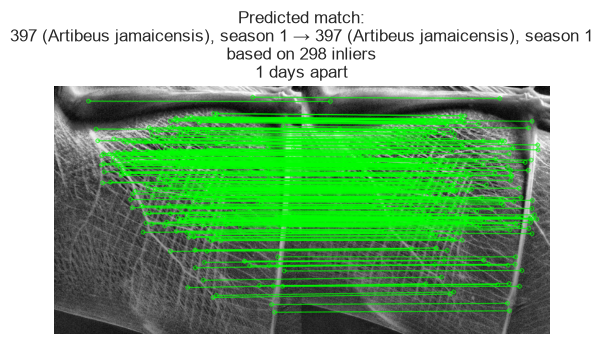

Files: D:\wingprint_paper\scanner_data\recaptures_gallery\Artibeus jamaicensis\397\season1_0\right\00001.png → D:\wingprint_paper\scanner_data\recaptures_query\Artibeus jamaicensis\397\season1_1\right\00001.png


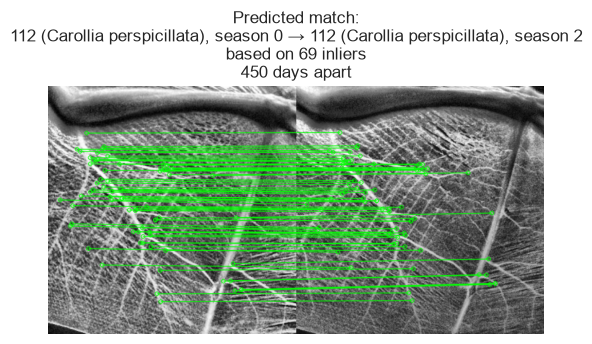

Files: D:\wingprint_paper\scanner_data\recaptures_gallery\Carollia perspicillata\112\season0_0\right\00000.png → D:\wingprint_paper\scanner_data\recaptures_query\Carollia perspicillata\112\season2_1\right\00001.png


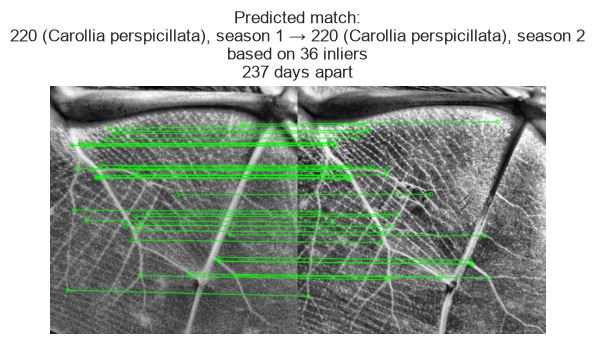

Files: D:\wingprint_paper\scanner_data\recaptures_gallery\Carollia perspicillata\220\season1_0\right\00002.png → D:\wingprint_paper\scanner_data\recaptures_query\Carollia perspicillata\220\season2_1\right\00001.png


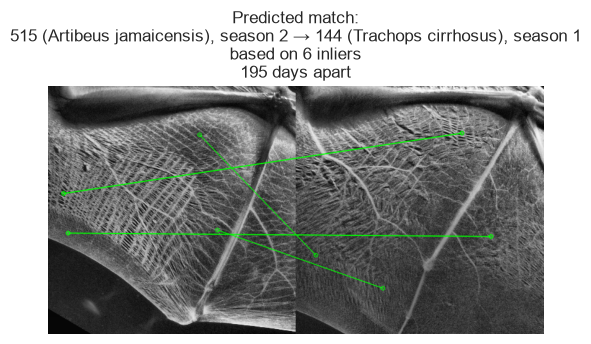

Files: D:\wingprint_paper\scanner_data\recaptures_gallery\Artibeus jamaicensis\515\season2_0\right\00001.png → D:\wingprint_paper\scanner_data\recaptures_query\Trachops cirrhosus\144\season1_1\right\00001.png


In [11]:
# Use these presets if you want to visualize different data:
#
# Predicted combinations:
#prediction_combos = [(seqs, i) for seqs, i in pairings.items() if i.prediction]
#
# Predictions with longest time difference:
#longest_prediction_combos = [(seqs, i) for seqs, i in pairings.items() if i.prediction and ScanImage(seqs[1], None, None, None).season == 0 and ScanImage(seqs[0], None, None, None).season == 2]
#
# Wrongly predicted combinations:
#wrong_prediction_combos = [(seqs, i) for seqs, i in pairings.items() if i.prediction and ScanImage(seqs[1], None, None, None).animal_id != ScanImage(seqs[0], None, None, None).animal_id]
#
# Random combinations:
#random_combinations = random.sample(prediction_combos, k=10)

df = df = pd.read_csv("timestamps.csv")

preds_to_visualize = [
    os.path.join(QUERY_DIR, r"Carollia perspicillata\220\season2_1"), # Carollia edge case
    os.path.join(QUERY_DIR, r"Artibeus jamaicensis\397\season1_1"), # Artibeus good case
    os.path.join(QUERY_DIR, r"Carollia perspicillata\112\season2_1"), # Carollia great time difference
    os.path.join(QUERY_DIR, r"Trachops cirrhosus\144\season1_1") # Trachops wrong match
]

combos_to_visualize = [(seqs, i) for seqs, i in pairings.items() if i.prediction and ScanImage(seqs[0], None, None, None).folder in preds_to_visualize]

for (query_sequence, gallery_sequence), pairingInfo in combos_to_visualize:
    query_scan = ScanImage(query_sequence, None, None, None)
    gallery_scan = ScanImage(gallery_sequence, None, None, None)
    
    img1 = cv2.imread(gallery_scan.file, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(query_scan.file, cv2.IMREAD_GRAYSCALE)

    kp1, des1 = compute_rootsift(img1, sift)
    kp2, des2 = compute_rootsift(img2, sift)

    matching_kps = matches(matcher, des1, des2)
    matching_kps = mutual_matches(*matching_kps, minimal_lowes)

    if len(matching_kps) >= 4:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in matching_kps]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in matching_kps]).reshape(-1, 1, 2)

        _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

        if mask is not None:
            inliers = [m for i, m in enumerate(matching_kps) if mask[i]]

            img_matches = cv2.drawMatches(
                img1, kp1, img2, kp2, inliers, None,
                matchColor=(0, 255, 0),  # green color for inliers
                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
            )

            query_timestamp = datetime.strptime(df.loc[(df["Bat ID"] == query_scan.animal_id) & (df["Season"] == query_scan.season) & (df["Scan Number"] == query_scan.scan_number), "Date [yyyy-mm-dd]"].iloc[0], '%Y-%m-%d').date()
            gallery_timestamp = datetime.strptime(df.loc[(df["Bat ID"] == gallery_scan.animal_id) & (df["Season"] == gallery_scan.season) & (df["Scan Number"] == gallery_scan.scan_number), "Date [yyyy-mm-dd]"].iloc[0], '%Y-%m-%d').date()

            day_difference = abs((query_timestamp-gallery_timestamp).days)

            fig = plt.figure()
            plt.imshow(img_matches)
            plt.title(f"Predicted match:\n{gallery_scan.animal_id} ({gallery_scan.species}), season {gallery_scan.season} → {query_scan.animal_id} ({query_scan.species}), season {query_scan.season}\nbased on {len(inliers)} inliers\n{day_difference} days apart")
            plt.axis('off')
            plt.show()
            plt.close(fig)

            print(f"Files: {gallery_scan.file} → {query_scan.file}")
